# 🎬 Movie Data Analysis Project
This project analyzes a movie dataset to understand trends in revenue, genres, and profitability.

## 📊 Dataset Overview

- Dataset contains movie information like title, budget, revenue, genres, ratings, etc.
- Goal: Extract meaningful insights from movie data.

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("TMDB  IMDB Movies Dataset.csv")

print(df.shape)
df.head()

(437232, 29)


,id,title,vote_average,vote_count,status,release_date,revenue,runtime,adult,backdrop_path,...,genres,production_companies,production_countries,spoken_languages,keywords,directors,writers,averageRating,numVotes,cast
0,27205,Inception,8.364,34495,Released,2010-07-15,825532764,148,False,/8ZTVqvKDQ8emSGUEMjsS4yHAwrp.jpg,...,"Action, Science Fiction, Adventure","Legendary Pictures, Syncopy, Warner Bros. Pict...","United Kingdom, United States of America","English, French, Japanese, Swahili","rescue, mission, dream, airplane, paris, franc...",Christopher Nolan,Christopher Nolan,8.8,2812592,"Leonardo DiCaprio, Joseph Gordon-Levitt, Ken W..."
1,157336,Interstellar,8.417,32571,Released,2014-11-05,701729206,169,False,/pbrkL804c8yAv3zBZR4QPEafpAR.jpg,...,"Adventure, Drama, Science Fiction","Legendary Pictures, Syncopy, Lynda Obst Produc...","United Kingdom, United States of America",English,"rescue, future, spacecraft, race against time,...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan",8.7,2522791,"Matthew McConaughey, Anne Hathaway, Michael Ca..."
2,155,The Dark Knight,8.512,30619,Released,2008-07-16,1004558444,152,False,/nMKdUUepR0i5zn0y1T4CsSB5chy.jpg,...,"Drama, Action, Crime, Thriller","DC Comics, Legendary Pictures, Syncopy, Isobel...","United Kingdom, United States of America","English, Mandarin","joker, sadism, chaos, secret identity, crime f...",Christopher Nolan,"Jonathan Nolan, Christopher Nolan, David S. Go...",9.1,3162942,"Christian Bale, Heath Ledger, Aaron Eckhart, M..."
3,19995,Avatar,7.573,29815,Released,2009-12-15,2923706026,162,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,...,"Action, Adventure, Fantasy, Science Fiction","Dune Entertainment, Lightstorm Entertainment, ...","United States of America, United Kingdom","English, Spanish","future, society, culture clash, space travel, ...",James Cameron,James Cameron,7.9,1496089,"Sam Worthington, Zoe Saldaña, Sigourney Weaver..."
4,24428,The Avengers,7.710,29166,Released,2012-04-25,1518815515,143,False,/9BBTo63ANSmhC4e6r62OJFuK2GL.jpg,...,"Science Fiction, Action, Adventure",Marvel Studios,United States of America,"English, Hindi, Russian","new york city, superhero, shield, based on com...",Joss Whedon,"Joss Whedon, Zak Penn",8.0,1556619,"Robert Downey Jr., Chris Evans, Mark Ruffalo, ..."


In [5]:
df.head()
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 437232 entries, 0 to 437231
Data columns (total 29 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    437232 non-null  int64  
 1   title                 437232 non-null  object 
 2   vote_average          437232 non-null  float64
 3   vote_count            437232 non-null  int64  
 4   status                437232 non-null  object 
 5   release_date          415425 non-null  object 
 6   revenue               437232 non-null  int64  
 7   runtime               437232 non-null  int64  
 8   adult                 437232 non-null  bool   
 9   backdrop_path         185455 non-null  object 
 10  budget                437232 non-null  int64  
 11  homepage              54840 non-null   object 
 12  tconst                437232 non-null  object 
 13  original_language     437232 non-null  object 
 14  original_title        437232 non-null  object 
 15  

,id,vote_average,vote_count,revenue,runtime,budget,popularity,averageRating,numVotes
count,4.372320e+05,437232.000000,437232.000000,4.372320e+05,437232.000000,4.372320e+05,437232.000000,437232.000000,4.372320e+05
mean,4.956528e+05,3.593499,48.739939,1.662558e+06,66.458132,6.506899e+05,2.189277,6.225964,3.118114e+03
std,3.666147e+05,3.151137,512.123460,2.621292e+07,64.181687,7.417129e+06,11.330075,1.310115,3.405870e+04
min,2.000000e+00,0.000000,0.000000,0.000000e+00,0.000000,0.000000e+00,0.000000,1.000000,5.000000e+00
25%,2.106255e+05,0.000000,0.000000,0.000000e+00,15.000000,0.000000e+00,0.600000,5.400000,2.400000e+01
50%,4.199610e+05,4.600000,1.000000,0.000000e+00,80.000000,0.000000e+00,0.852000,6.300000,7.000000e+01
75%,7.136505e+05,6.200000,5.000000,0.000000e+00,96.000000,0.000000e+00,1.653000,7.100000,3.240000e+02
max,1.685760e+06,10.000000,34495.000000,2.923706e+09,14400.000000,8.880000e+08,2994.357000,10.000000,3.183709e+06


## Data Cleaning
Removed missing values and filtered invalid budget/revenue entries.

In [6]:
df = df.dropna(subset=['genres', 'budget', 'revenue'])
df = df[(df['budget'] > 0) & (df['revenue'] > 0)]

## Feature Engineering

We create new features such as profit, ROI, and year.

In [7]:
df['profit'] = df['revenue'] - df['budget']
df['roi'] = (df['profit'] / df['budget']) * 100
df['year'] = pd.to_datetime(df['release_date']).dt.year

## Data Analysis

### Top Movie Genres

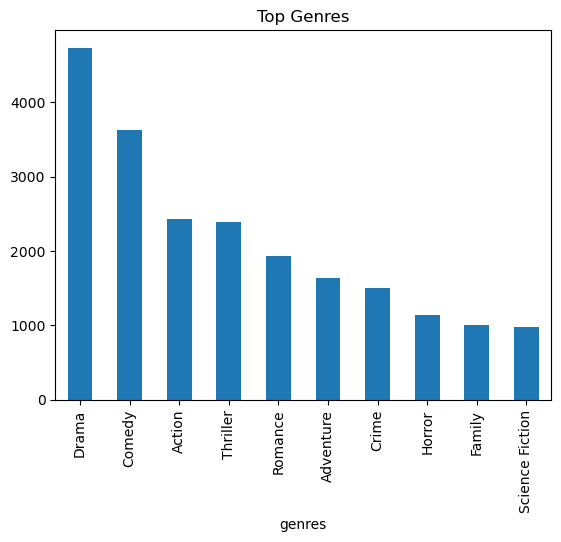

In [8]:
df['genres'] = df['genres'].str.split(',')
df_exploded = df.explode('genres')
df_exploded['genres'] = df_exploded['genres'].str.strip()

df_exploded['genres'].value_counts().head(10).plot(kind='bar')
import matplotlib.pyplot as plt
plt.title("Top Genres")
plt.show()

**Insight:**
- Drama is the most common genre.
- Comedy and Action are also highly frequent.

### Most Profitable Genres

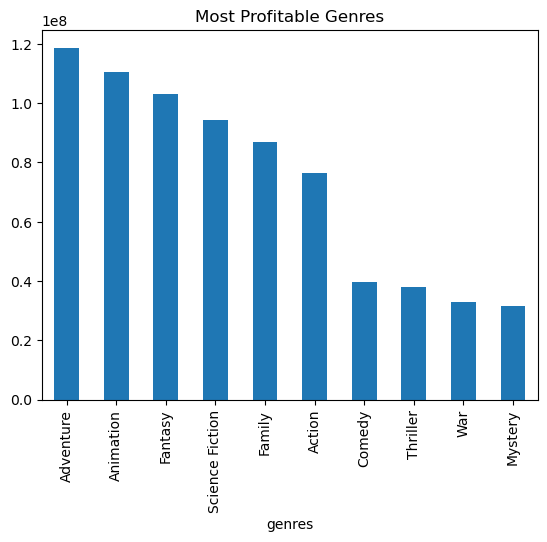

In [9]:
df_exploded.groupby('genres')['profit'].mean().sort_values(ascending=False).head(10)
df_exploded.groupby('genres')['profit'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Most Profitable Genres")
plt.show()

**Insight:**
- Adventure and Animation genres generate highest profits.
- Genre plays a strong role in movie success.

### Rating vs Revenue

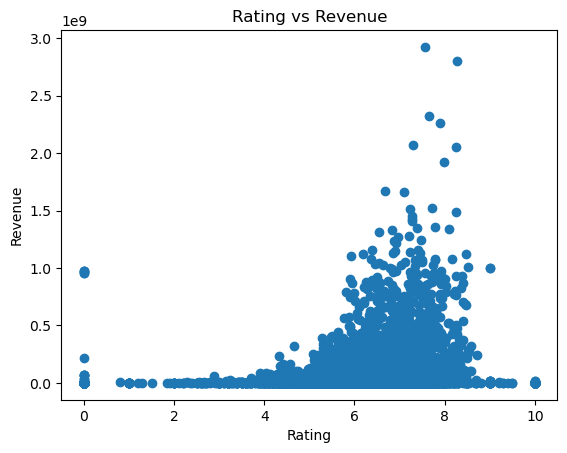

In [10]:
plt.scatter(df['vote_average'], df['revenue'])
plt.xlabel("Rating")
plt.ylabel("Revenue")
plt.title("Rating vs Revenue")
plt.show()

**Insight:**
- High rating ≠ high revenue always.

### 📅 Revenue Trend Over Time

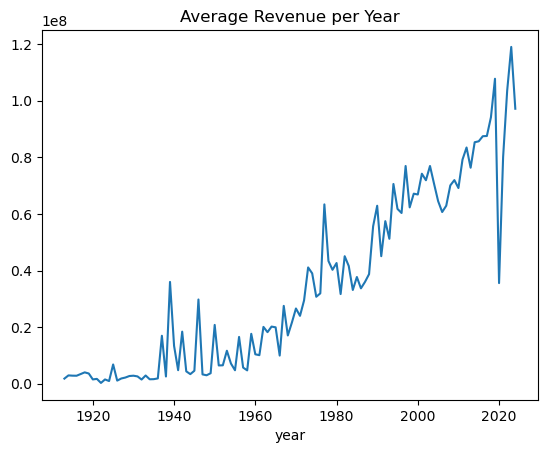

In [11]:
df.groupby('year')['revenue'].mean().plot()
plt.title("Average Revenue per Year")
plt.show()

**Insight:**
- Revenue increased over time.

### 🏆 Top Profit Movies

In [12]:
df[['title','profit']].sort_values(by='profit', ascending=False).head(10)

,title,profit
3,Avatar,2686706026
15,Avengers: Endgame,2444000000
17,Titanic,2064162353
282,Avatar: The Way of Water,1860250281
56,Star Wars: The Force Awakens,1823223624
6,Avengers: Infinity War,1752415039
57,Spider-Man: No Way Home,1721847111
44,Jurassic World,1521537444
317,The Lion King,1403075401
271,Furious 7,1325341399


**Insight:**
- High budget movies generate highest profits.

## ✅ Conclusion

- Drama is the most common genre.
- Adventure and Animation are most profitable.
- Ratings do not guarantee revenue.
- Movie industry revenue has grown over time.

## 🚀 Future Improvements

- Build movie recommendation system
- Use machine learning for prediction
- Create dashboard (Power BI / Streamlit)